**Import Libraries**

In [1]:
import os
import shutil
from pathlib import Path

import pandas as pd
import numpy as np

from PIL import Image

from sklearn.model_selection import train_test_split

In [2]:
from pathlib import Path

PROJECT_ROOT = Path("/voc/work/Capstone1")
DATA_PATH = PROJECT_ROOT / "Data"
IMAGES_PATH = DATA_PATH / "Images"
LABELS_PATH = DATA_PATH / "labels_filtered.csv"
YOLO_PATH = DATA_PATH / "yolo_dataset"

In [3]:
labels = pd.read_csv(LABELS_PATH)

labels.head()

,image_id,class_name,xmin,ymin,xmax,ymax
0,0,pickup_truck,213,34,255,50
1,0,car,194,78,273,122
2,0,car,155,27,183,35
3,0,articulated_truck,43,25,109,55
4,0,car,106,32,124,45


In [4]:
print(labels.shape)
print(labels["image_id"].nunique())

(17967, 6)
5626


**Class mapping**

In [6]:
classes = sorted(labels["class_name"].unique())

class_to_id = {
    cls: idx
    for idx, cls in enumerate(classes)
}

id_to_class = {
    idx: cls
    for cls, idx in class_to_id.items()
}

print(class_to_id)

{'articulated_truck': 0, 'bicycle': 1, 'bus': 2, 'car': 3, 'motorcycle': 4, 'motorized_vehicle': 5, 'non-motorized_vehicle': 6, 'pedestrian': 7, 'pickup_truck': 8, 'single_unit_truck': 9, 'work_van': 10}


In [7]:
import json

with open(DATA_PATH/"class_mapping.json","w") as f:
    json.dump(class_to_id,f,indent=4)

In [8]:
#check yolo data directories
print(list(YOLO_PATH.iterdir()))

[PosixPath('/voc/work/Capstone1/Data/yolo_dataset/test'), PosixPath('/voc/work/Capstone1/Data/yolo_dataset/valid'), PosixPath('/voc/work/Capstone1/Data/yolo_dataset/train')]


**Dataset split**

In [11]:
image_ids = labels["image_id"].unique()
print(image_ids)

[   0    1    2 ... 5655 5656 5657]


In [12]:
train_ids, temp_ids = train_test_split(
    image_ids,
    test_size=0.2,
    random_state=42
)

valid_ids, test_ids = train_test_split(
    temp_ids,
    test_size=0.5,
    random_state=42
)

In [13]:
print("Train:",len(train_ids))
print("Valid:",len(valid_ids))
print("Test:",len(test_ids))

Train: 4500
Valid: 563
Test: 563


In [14]:
#copy the images to split folders
def copy_images(image_ids, split):

    destination = YOLO_PATH / split / "images"

    for image_id in image_ids:

        filename = f"{image_id:08d}.jpg"

        shutil.copy(
            IMAGES_PATH / filename,
            destination / filename
        )

In [15]:
copy_images(train_ids,"train")

copy_images(valid_ids,"valid")

copy_images(test_ids,"test")

In [20]:
print(len(os.listdir(YOLO_PATH/"train"/"images")))

4500


creating yolo labels for each image where all coordinates are normalized between 0 and 1.

**Creating conversion function**

In [21]:
def convert_to_yolo(xmin, ymin, xmax, ymax, img_width, img_height):

    x_center = ((xmin + xmax) / 2) / img_width
    y_center = ((ymin + ymax) / 2) / img_height

    width = (xmax - xmin) / img_width
    height = (ymax - ymin) / img_height

    return x_center, y_center, width, height

In [22]:
#testing
convert_to_yolo(
    xmin=194,
    ymin=78,
    xmax=273,
    ymax=122,
    img_width=342,
    img_height=228
)

(0.6827485380116959,
 0.43859649122807015,
 0.2309941520467836,
 0.19298245614035087)

In [23]:
#creating text labels for each image
def create_yolo_labels(image_ids, split):

    image_folder = YOLO_PATH / split / "images"
    label_folder = YOLO_PATH / split / "labels"

    for image_id in image_ids:

        image_name = f"{image_id:08d}.jpg"

        image_path = image_folder / image_name

        img = Image.open(image_path)

        img_width, img_height = img.size

        rows = labels[
            labels["image_id"] == image_id
        ]

        label_file = label_folder / f"{image_id:08d}.txt"

        with open(label_file, "w") as f:

            for _, row in rows.iterrows():

                class_id = class_to_id[row["class_name"]]

                x, y, w, h = convert_to_yolo(
                    row["xmin"],
                    row["ymin"],
                    row["xmax"],
                    row["ymax"],
                    img_width,
                    img_height
                )

                f.write(
                    f"{class_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n"
                )

In [24]:
create_yolo_labels(train_ids, "train")

create_yolo_labels(valid_ids, "valid")

create_yolo_labels(test_ids, "test")

In [26]:
#verifying labels were created
print(len(os.listdir(YOLO_PATH/"train"/"labels")))
print(len(os.listdir(YOLO_PATH/"valid"/"labels")))
print(len(os.listdir(YOLO_PATH/"test"/"labels")))

4500
563
563


In [30]:
#opening a labeled file
sample = sorted(os.listdir(YOLO_PATH/"train"/"labels"))[0]
print(sample)

with open(
    YOLO_PATH/"train"/"labels"/sample
) as f:

    print(f.read())

00000000.txt
8 0.684211 0.184211 0.122807 0.070175
3 0.682749 0.438596 0.230994 0.192982
3 0.494152 0.135965 0.081871 0.035088
0 0.222222 0.175439 0.192982 0.131579
3 0.336257 0.168860 0.052632 0.057018



In [31]:
sample_file = sorted(os.listdir(YOLO_PATH/"train"/"labels"))[0]

with open(YOLO_PATH/"train"/"labels"/sample_file) as f:
    lines = f.readlines()

for line in lines:
    values = list(map(float, line.split()[1:]))

    print(values)

[0.684211, 0.184211, 0.122807, 0.070175]
[0.682749, 0.438596, 0.230994, 0.192982]
[0.494152, 0.135965, 0.081871, 0.035088]
[0.222222, 0.175439, 0.192982, 0.131579]
[0.336257, 0.16886, 0.052632, 0.057018]


In [32]:
#creating a data.yaml file
import yaml

data_yaml = {
    "path": str(YOLO_PATH.resolve()),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": {i: cls for i, cls in enumerate(classes)}
}

with open(DATA_PATH / "data.yaml", "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print("data.yaml created successfully!")

data.yaml created successfully!


In [41]:
#verifying if the conversions work with yolo pipeline
import random
from pathlib import Path

train_images = list((YOLO_PATH / "train" / "images").glob("*.jpg"))

sample_image = random.choice(train_images)

print(sample_image.name)

00001327.jpg


(-0.5, 719.5, 479.5, -0.5)

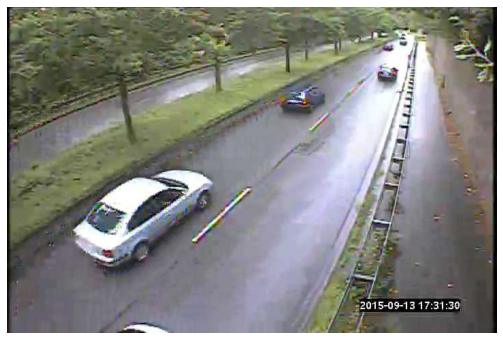

In [42]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(sample_image)

plt.figure(figsize=(10,6))
plt.imshow(img)
plt.axis("off")

In [43]:
label_file = (
    YOLO_PATH
    / "train"
    / "labels"
    / sample_image.with_suffix(".txt").name
)

print(label_file)

/voc/work/Capstone1/Data/yolo_dataset/train/labels/00001327.txt


In [44]:
with open(label_file) as f:
    lines = f.readlines()

print(lines)

['3 0.604861 0.284375 0.090278 0.085417\n', '3 0.775694 0.204167 0.043056 0.058333\n', '3 0.273611 0.650000 0.288889 0.308333\n', '5 0.276389 0.981250 0.102778 0.033333\n', '3 0.775000 0.118750 0.022222 0.029167\n']


In [45]:
def yolo_to_bbox(x_center, y_center, width, height,
                 img_width, img_height):

    x_center *= img_width
    y_center *= img_height

    width *= img_width
    height *= img_height

    xmin = x_center - width / 2
    ymin = y_center - height / 2

    xmax = x_center + width / 2
    ymax = y_center + height / 2

    return xmin, ymin, xmax, ymax

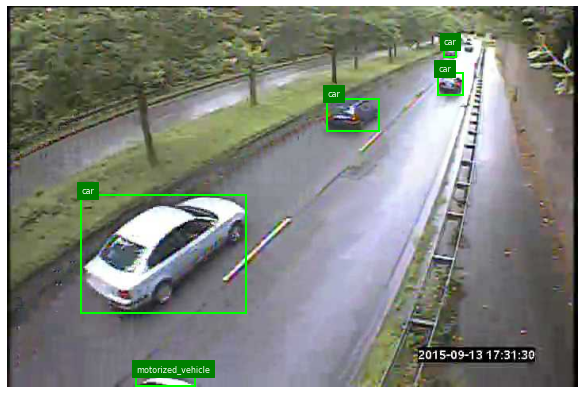

In [46]:
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(12,7))

ax.imshow(img)

img_width, img_height = img.size

for line in lines:

    values = line.strip().split()

    class_id = int(values[0])

    x = float(values[1])
    y = float(values[2])
    w = float(values[3])
    h = float(values[4])

    xmin, ymin, xmax, ymax = yolo_to_bbox(
        x,
        y,
        w,
        h,
        img_width,
        img_height
    )

    rect = patches.Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        linewidth=2,
        edgecolor="lime",
        facecolor="none"
    )

    ax.add_patch(rect)

    ax.text(
        xmin,
        ymin - 3,
        id_to_class[class_id],
        color="white",
        fontsize=8,
        backgroundcolor="green"
    )

plt.axis("off")
plt.show()

In [50]:
import shutil

shutil.make_archive(
    base_name=DATA_PATH / "yolo_dataset",
    format="zip",
    root_dir=YOLO_PATH
)

print("Dataset zipped successfully!")

Dataset zipped successfully!
